In [41]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS

from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [42]:
docs = (
    PyPDFLoader("../documents/Company_Policies.pdf").load()
    + PyPDFLoader("../documents/Company_Profile.pdf").load()
    + PyPDFLoader("../documents/Product_and_Pricing.pdf").load()
)


In [43]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [44]:
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)

vector_store = FAISS.from_documents(chunks, embeddings)

retriever = vector_store.as_retriever(
    search_kwargs={"k": 4}
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5770.17it/s]


In [45]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [46]:
# -----------------------------
# Graph State
# -----------------------------
class State(TypedDict):
    question: str

    # ✅ NEW: what we actually send to vector retriever
    retrieval_query: str
    rewrite_tries: int
    
    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str

    # Post-generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    isuse: Literal["useful", "not_useful"]
    use_reason: str
    web_query: str

In [47]:
# -----------------------------
# 1) Decide retrieval
# -----------------------------
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON with key: should_retrieve (boolean).\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts from company documents.\n"
            "- should_retrieve=False for general explanations/definitions.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: State):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    return "retrieve" if state["need_retrieval"] else "generate_direct"

In [48]:
# -----------------------------
# 2) Direct answer (no retrieval)
# -----------------------------
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer using only your general knowledge.\n"
            "If it requires specific company info, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate_direct(state: State):
    out = llm.invoke(direct_generation_prompt.format_messages(question=state["question"]))
    return {"answer": out.content}

In [49]:
# -----------------------------
# 3) Retrieve
# -----------------------------
def retrieve(state: State):
    q = state.get("retrieval_query") or state["question"]
    return {"docs": retriever.invoke(q)}

In [50]:
# -----------------------------
# 4) Relevance filter (strict)
# -----------------------------
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True ONLY if the document contains info that can directly answer the question."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    relevant_docs: List[Document] = []
    for doc in state.get("docs", []):
        try:
            decision: RelevanceDecision = relevance_llm.invoke(
                is_relevant_prompt.format_messages(
                    question=state["question"],
                    document=doc.page_content,
                )
            )
            if decision.is_relevant:
                relevant_docs.append(doc)
        except Exception:
            relevant_docs.append(doc)
    return {"relevant_docs": relevant_docs}

def route_after_relevance(state: State) -> Literal["generate_from_context", "rewrite_query"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "rewrite_query"


In [51]:
# -----------------------------
# 5) Generate from context
# -----------------------------
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business rag chatbot.\n\n"
            "You will receive a CONTEXT block from internal company documents.\n"
            "Task:\n"
            "Answer the question based on the context\n"
            "Dont mention that you are getting a context in your answer"
        ),
        ("human", "Question:\n{question}\n\nContext:\n{context}"),
    ]
)

def generate_from_context(state: State):
    context = "\n\n---\n\n".join([d.page_content for d in state.get("relevant_docs", [])]).strip()
    if not context:
        return {"answer": "No answer found.", "context": ""}
    out = llm.invoke(
        rag_generation_prompt.format_messages(question=state["question"], context=context)
    )
    return {"answer": out.content, "context": context}

# -----------------------------
# Web fallback (Tavily search)
# -----------------------------
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency, add (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Output ONLY the search query keywords, nothing else."
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm

def rewrite_query_node(state: State):
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.content.strip()}

tavily = TavilySearch(max_results=5)

def web_search_node(state: State):
    q = state.get("web_query") or state["question"]
    response = tavily.invoke({"query": q})
    
    docs = []
    for r in response.get("results", []):
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")

        text = (
            f"TITLE: {title}\n"
            f"URL: {url}\n"
            f"CONTENT:\n{content}"
        )

        docs.append(
            Document(
                page_content=text,
                metadata={"source": "web", "url": url, "title": title},
            )
        )

    return {"relevant_docs": docs}


In [52]:
# -----------------------------
# 6) IsSUP verify + revise loop
# -----------------------------
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)


issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state: State):
    try:
        decision: IsSUPDecision = issup_llm.invoke(
            issup_prompt.format_messages(
                question=state["question"],
                answer=state.get("answer", ""),
                context=state.get("context", ""),
            )
        )
        return {"issup": decision.issup, "evidence": decision.evidence}
    except Exception:
        return {"issup": "fully_supported", "evidence": []}


MAX_RETRIES = 10

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # fully supported -> move forward to IsUSE (via "accept_answer" label)
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"  # will go to is_use, then likely not_useful -> no_answer_found

    return "revise_answer"

In [53]:
def accept_answer(state: State):
    return {}  # keep answer as-is

In [54]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)



def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # ✅ increment
    }

In [55]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = llm.with_structured_output(IsUSEDecision)

def is_use(state: State):
    try:
        decision: IsUSEDecision = isuse_llm.invoke(
            isuse_prompt.format_messages(
                question=state["question"],
                answer=state.get("answer", ""),
            )
        )
        return {"isuse": decision.isuse, "use_reason": decision.reason}
    except Exception:
        return {"isuse": "useful", "use_reason": "default useful fallback"}

MAX_REWRITE_TRIES = 3  # tune (2–4 is usually fine)

def route_after_isuse(state: State) -> Literal["END", "rewrite_question", "rewrite_query"]:
    if state.get("isuse") == "useful":
        return "END"

    # If we already ran web search fallback, end here
    if state.get("web_query"):
        return "END"

    # If local vector retrieval rewrites exhausted, fall back to web search
    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "rewrite_query"

    return "rewrite_question"


In [56]:
rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a search query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., company names, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in company/policy/profile docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output ONLY the rewritten search query keywords, nothing else."
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)

rewrite_for_retrieval_chain = rewrite_for_retrieval_prompt | llm

def rewrite_question(state: State):
    try:
        out = rewrite_for_retrieval_chain.invoke(
            {
                "question": state["question"],
                "retrieval_query": state.get("retrieval_query", ""),
                "answer": state.get("answer", ""),
            }
        )
        new_query = out.content.strip()
    except Exception:
        new_query = state["question"]

    return {
        "retrieval_query": new_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # reset these so next retrieval pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }


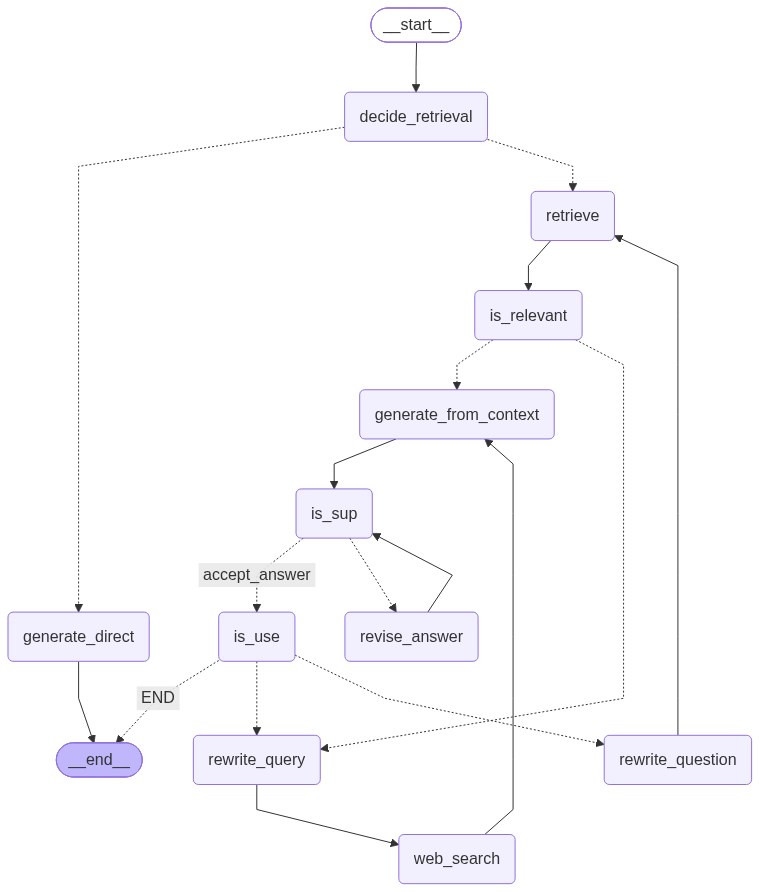

In [57]:
# -----------------------------
# Build graph (UPDATED: Local retrieval with rewrite + Tavily fallback)
# -----------------------------
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)
g.add_node("generate_from_context", generate_from_context)

# IsSUP + revise loop
g.add_node("is_sup", is_sup)
g.add_node("revise_answer", revise_answer)

# IsUSE
g.add_node("is_use", is_use)

# Rewrite question for better internal retrieval
g.add_node("rewrite_question", rewrite_question)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {"generate_direct": "generate_direct", "retrieve": "retrieve"},
)

g.add_edge("generate_direct", END)

# Retrieve -> relevance -> (generate | web fallback)
g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "rewrite_query": "rewrite_query",
    },
)

# Web fallback flow: rewrite_query -> web_search -> generate_from_context
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "generate_from_context")

# --------------------
# Generate -> IsSUP -> (IsUSE | revise) loop
# --------------------
g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {
        "accept_answer": "is_use",      # fully_supported (or max retries) -> go to IsUSE
        "revise_answer": "revise_answer",
    },
)

g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to IsSUP

# --------------------
# IsUSE routing
#   - useful -> END
#   - not_useful -> rewrite_question -> retrieve (retry internal docs)
#   - rewrites exhausted -> rewrite_query (fallback to Tavily web search)
# --------------------
g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        "rewrite_question": "rewrite_question",
        "rewrite_query": "rewrite_query",
    },
)

# rewrite -> retrieve -> relevance -> ...
g.add_edge("rewrite_question", "retrieve")

app = g.compile()
app


In [58]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Who is the Founder of AbhiIterates",
    "retrieval_query": "What is the refund policy of AbhiIterates",  # ✅ important
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "web_query": "",
    "isuse": "not_useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")


===== RAG EXECUTION RESULT =====

Question: Who is the Founder of AbhiIterates
Need Retrieval: True
Rewrite tries (retrieval): 1
Support revise tries: 0

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 3

Relevant docs (source/page):
  1. source=../documents/Company_Profile.pdf, page=0, title=AbhiIterates - Company Profile
  2. source=../documents/Company_Profile.pdf, page=0, title=AbhiIterates - Company Profile
  3. source=../documents/Company_Profile.pdf, page=1, title=AbhiIterates - Company Profile

Verification (IsSUP):
  issup: fully_supported
  evidence:
   - Founder Abhishek Kr Prajapati (Abhishek) founded AbhiIterates.
   - Abhishek Kr Prajapati (Abhishek) founded AbhiIterates.

Usefulness (IsUSE):
  isuse: useful
  reason: Directly provides the founder's name as requested.

Final Answer:
The founder of AbhiIterates is **Abhishek Kr Prajapati (Abhishek)**.


